In [1]:
import pandas as pd
from plotnine import *

In [2]:
custom_colors = [
    "#1D2951",  # Space Cadet (dark blue)
    "#FFD166",  # Warm Yellow
    "#4BA3C3",  # Sky Blue
    "#F25C54",  # Coral Red
    "#007C91",  # Deep Teal
    "#EF798A",  # Dusty Rose
    "#6DCDB8",  # Mint Green
    "#FF9F1C",  # Vivid Orange
    "#6B4C9A",  # Violet Indigo
    "#A4C400",  # Lime Green
    "#8E7DBE",  # Lavender Purple
    "#2E8B57",  # Sea Green
]

In [3]:
figure_theme = theme_minimal() + theme(
    plot_background=element_rect(fill="#ffffff", color="#ffffff"),
    plot_title=element_text(hjust=0, size=14, face="bold"),
    legend_title=element_text(size=11, face="plain"),
    axis_title=element_text(size=10, face="plain"),
    axis_text=element_text(size=9, face="plain"),
)

## Count Distributions

In [3]:
# Load cell count distribution
cell_counts = pd.read_feather(
    "../output/EDA_mouse_liver_ST/final_run_2025-05-22_23-42/pdata_counts_per_cell.feather"
)
cell_counts

,value,dataset,disease_state
0,450.0,liver1,healthy
1,780.0,liver1,healthy
2,752.0,liver1,healthy
3,725.0,liver1,healthy
4,395.0,liver1,healthy
...,...,...,...
67780,579.0,liver2,cirrhosis
67781,1015.0,liver2,cirrhosis
67782,954.0,liver2,cirrhosis
67783,2247.0,liver2,cirrhosis


In [5]:
# Load feature count distribution
feat_counts = pd.read_feather(
    "../output/EDA_mouse_liver_ST/final_run_2025-05-22_23-42/pdata_features_per_cell.feather"
)
feat_counts

,value,dataset
0,181,liver1
1,241,liver1
2,260,liver1
3,323,liver1
4,142,liver1
...,...,...
67780,222,liver2
67781,270,liver2
67782,264,liver2
67783,418,liver2


In [6]:
# Load gene count distribution
gene_counts = pd.read_feather(
    "../output/EDA_mouse_liver_ST/final_run_2025-05-22_23-42/pdata_counts_per_gene.feather"
)
gene_counts

,raw_counts,dataset,value
0,9926.0,liver1,3.996818
1,23954.0,liver1,4.379396
2,4548.0,liver1,3.657916
3,8327.0,liver1,3.920541
4,2801.0,liver1,3.447468
...,...,...,...
1935,2357.0,liver2,3.372544
1936,4655.0,liver2,3.668013
1937,2073.0,liver2,3.316809
1938,1271.0,liver2,3.104487


In [10]:
dfs = [cell_counts, feat_counts, gene_counts]
categories = ["Counts per Cell", "Counts per Gene", "Non-zero Features per Cell"]

for i in range(len(dfs)):
    dfs[i]["scope"] = categories[i]

summarized = pd.concat(dfs, ignore_index=True)
summarized = summarized[["value", "scope", "dataset"]]
summarized

,value,scope,dataset
0,450.000000,Counts per Cell,liver1
1,780.000000,Counts per Cell,liver1
2,752.000000,Counts per Cell,liver1
3,725.000000,Counts per Cell,liver1
4,395.000000,Counts per Cell,liver1
...,...,...,...
137505,3.372544,Non-zero Features per Cell,liver2
137506,3.668013,Non-zero Features per Cell,liver2
137507,3.316809,Non-zero Features per Cell,liver2
137508,3.104487,Non-zero Features per Cell,liver2


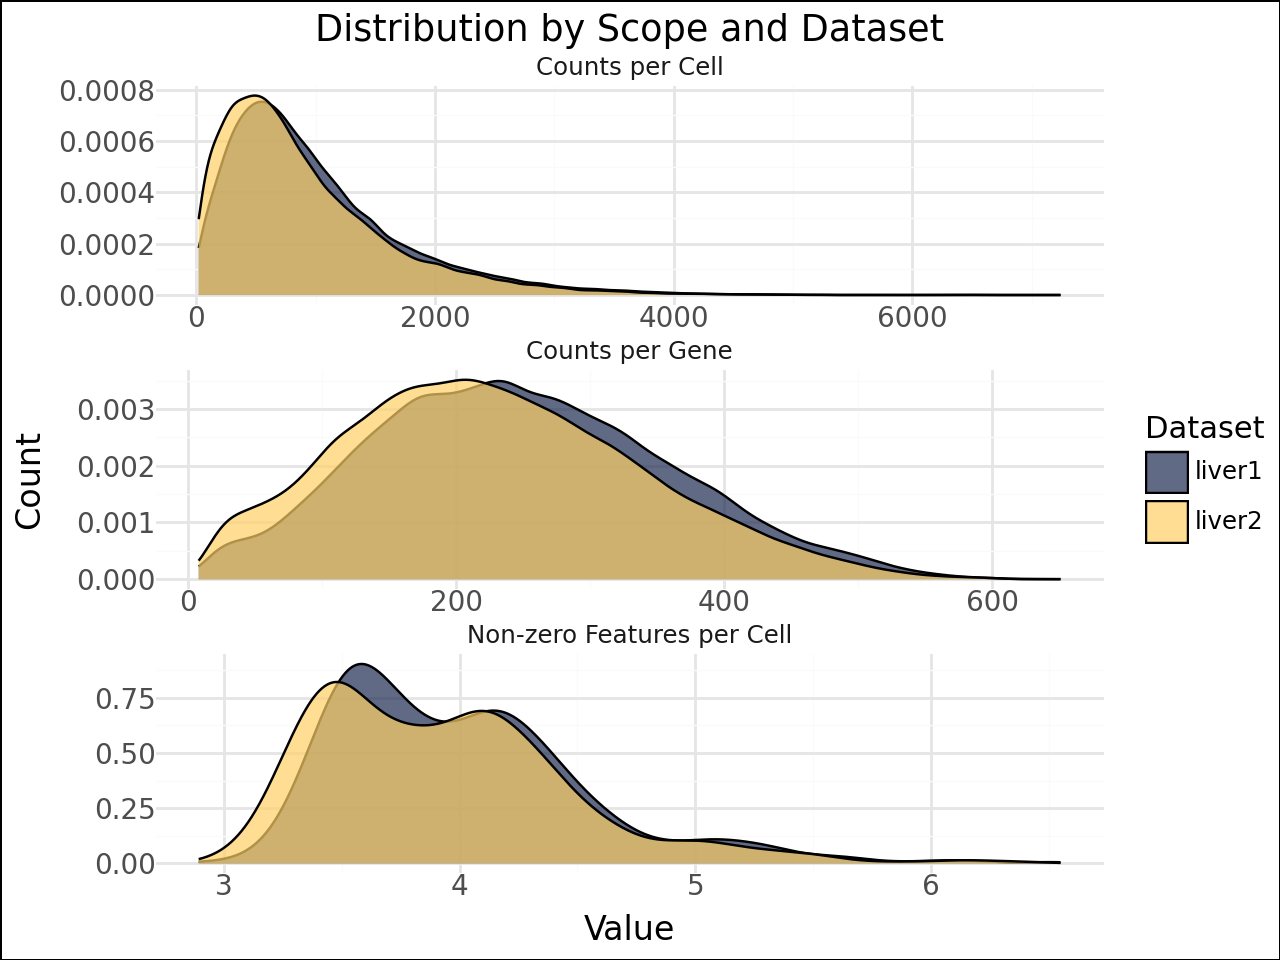

In [16]:
custom_colors = {"liver1": "#1D2951", "liver2": "#FFD166"}

# Create the plot
p = (
    ggplot(summarized, aes(x="value", fill="dataset"))
    + geom_density(alpha=0.7)
    + facet_wrap("~scope", scales="free", ncol=1)  # Independent axes
    + scale_fill_manual(values=custom_colors)
    + labs(
        x="Value", y="Count", fill="Dataset", title="Distribution by Scope and Dataset"
    )
    + theme_minimal()
    + theme(
        plot_background=element_rect(fill="white"),
        panel_background=element_rect(fill="white"),
        axis_title=element_text(size=12),
        axis_text=element_text(size=10),
        # strip_text=element_text(size=13, weight="bold"),
        legend_title=element_text(size=11),
        legend_position="right",
    )
)

p

## Cells per Field of View

In [56]:
# Load data
data = pd.read_feather("data/pdata_cells_per_fov.feather")
data

,group,dataset,value
0,10,liver1,705
1,10,liver2,897
2,11,liver1,787
3,11,liver2,669
4,12,liver1,925
...,...,...,...
85,7,liver2,786
86,8,liver1,1038
87,8,liver2,801
88,9,liver1,810


In [ ]:
# Preprocess data

data["dataset"] = data["dataset"].replace({"liver1": "Liver1", "liver2": "Liver2"})

# Order groups by descending order
data["group"] = data["group"].astype(int)
data["group"] = pd.Categorical(
    data["group"], categories=sorted(data["group"].unique(), reverse=True), ordered=True
)

/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: output/#cells_per_fov.png


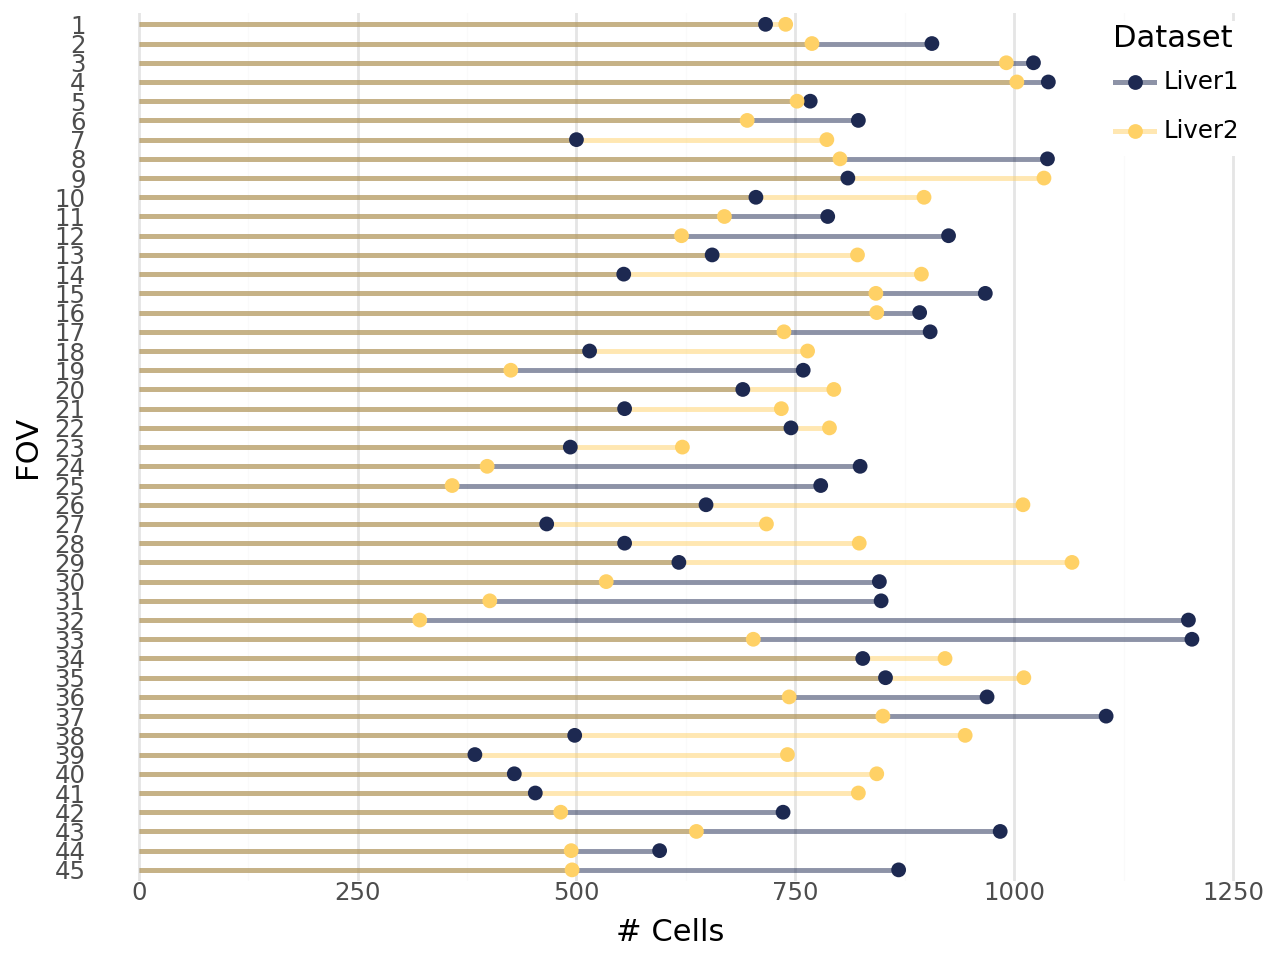

In [ ]:
plot = (
    ggplot(data, aes(y="group", x="value", color="dataset"))
    + geom_segment(aes(x=0, xend="value", y="group", yend="group"), size=1, alpha=0.5)
    + geom_point(size=2)
    + scale_x_continuous(limits=(0, data["value"].max() + 10))
    + scale_y_discrete()
    + scale_color_manual(values={"Liver1": "#1D2951", "Liver2": "#FFD166"})
    + theme_minimal()
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major_y=element_blank(),
        legend_position=(0.99, 0.99),
        legend_justification=(1, 1),
        legend_background=element_rect(fill="white", color="none"),
    )
    + labs(x="# Cells", y="FOV", color="Dataset")
)

ggsave(plot, "output/#cells_per_fov.svg")

plot

## UMAPs Before Integration

In [4]:
data = pd.read_feather("data/pdata_umaps_ST.feather")
data["condition"] = data["condition"].map(
    {
        "healthy": "Healthy",
        "steatosis": "Steatosis",
        "cirrhosis": "Cirrhosis",
        "aclf": "ACLF",
    }
)
data

,slide,fov,condition,umap_1,umap_2
liver1_3_1,S2,1_liver1,Healthy,0.167600,8.806798
liver1_4_1,S2,1_liver1,Healthy,-0.847367,6.216402
liver1_5_1,S2,1_liver1,Healthy,0.175900,6.586068
liver1_7_1,S2,1_liver1,Healthy,2.945525,9.352727
liver1_8_1,S2,1_liver1,Healthy,-0.567749,9.055143
...,...,...,...,...,...
liver2_531_45,S3,45_liver2,Cirrhosis,0.605701,7.784894
liver2_532_45,S3,45_liver2,Cirrhosis,-2.704872,4.453344
liver2_533_45,S3,45_liver2,Cirrhosis,1.871059,6.471807
liver2_534_45,S3,45_liver2,Cirrhosis,-1.875127,1.386655


/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: output/initial_umap_slide.svg


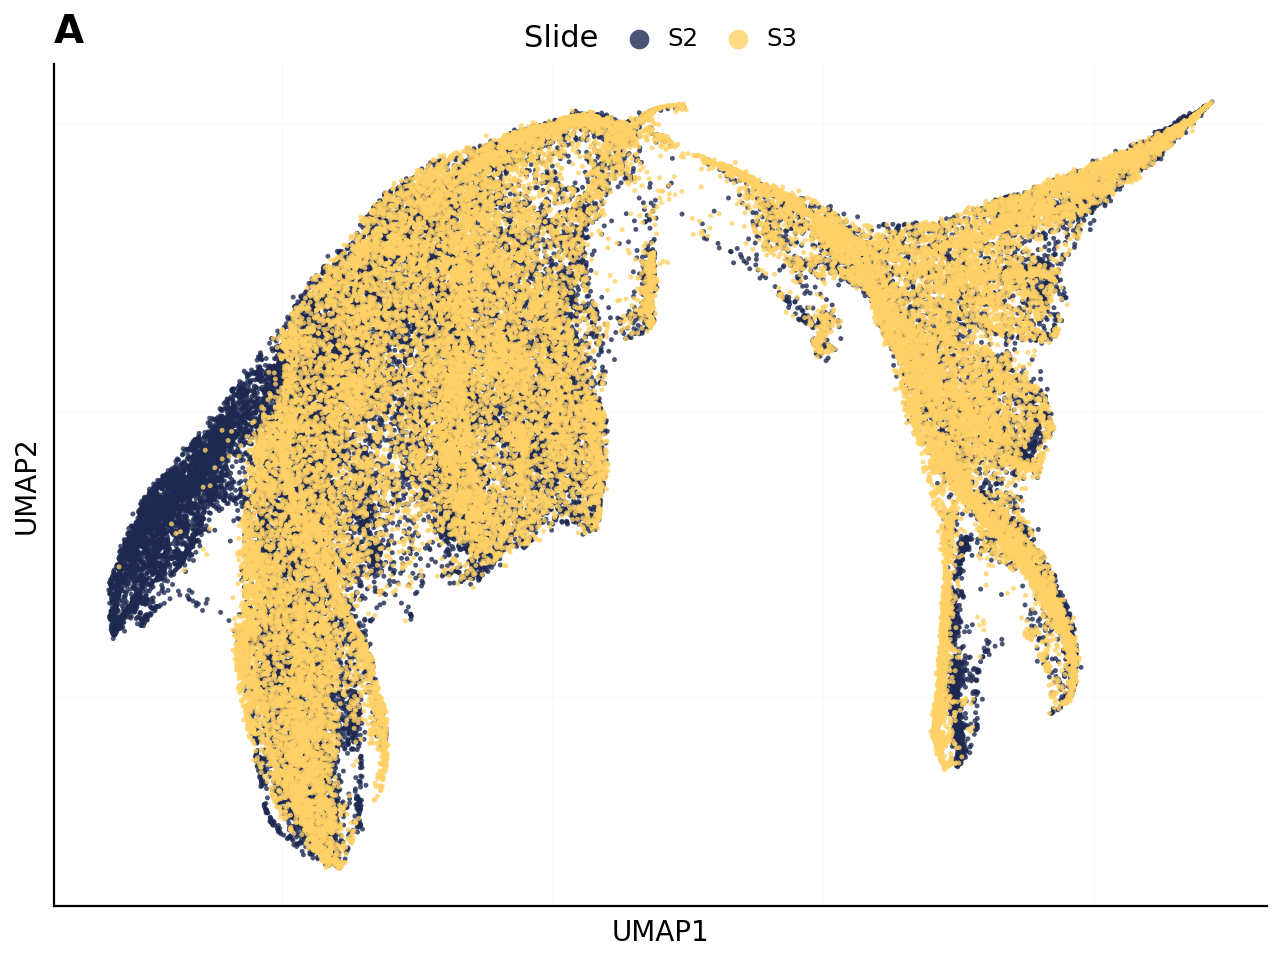

In [5]:
plot = (
    ggplot(data, aes(x="umap_1", y="umap_2", fill="slide"))
    + geom_point(alpha=0.8, size=1, stroke=0)
    + scale_fill_manual(values=custom_colors[:2])
    + labs(title="A", x="UMAP1", y="UMAP2", fill="Slide")
    + guides(fill=guide_legend(override_aes={"size": 4}))
    + figure_theme
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
        legend_position=(0.5, 1),
        legend_justification=(0.5, 0),
        legend_direction="horizontal",
        legend_background=element_rect(fill="white", color="none"),
    )
)

ggsave(plot, "output/initial_umap_slide.svg")

plot

/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: output/initial_umap_fov.svg


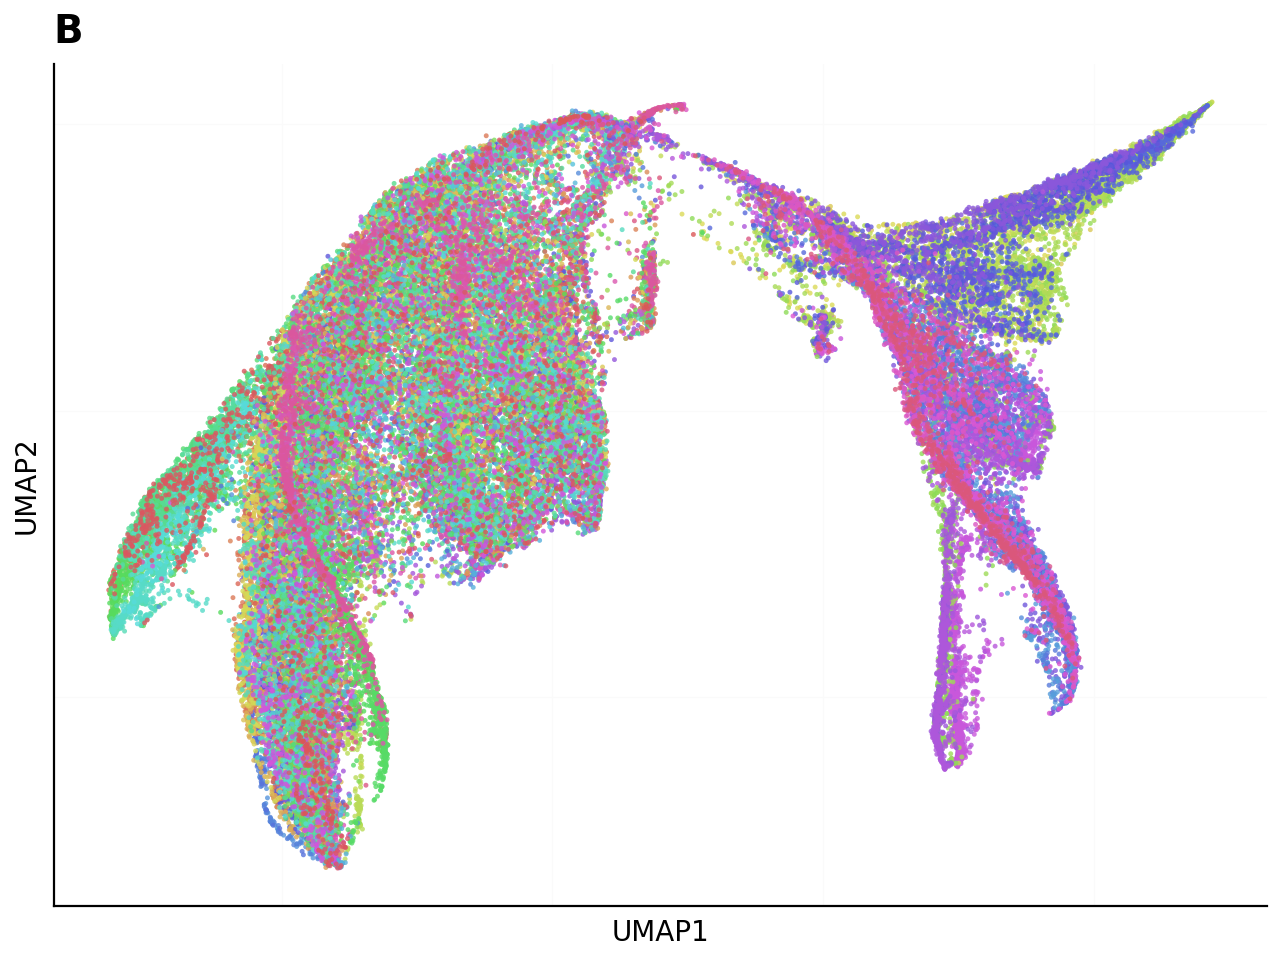

In [7]:
plot = (
    ggplot(data, aes(x="umap_1", y="umap_2", fill="fov"))
    + geom_point(alpha=0.8, size=1, stroke=0)
    + labs(title="B", x="UMAP1", y="UMAP2")
    + figure_theme
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
        legend_position="none",
    )
)

ggsave(plot, "output/initial_umap_fov.svg")

plot

/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: output/initial_umap_condition.svg


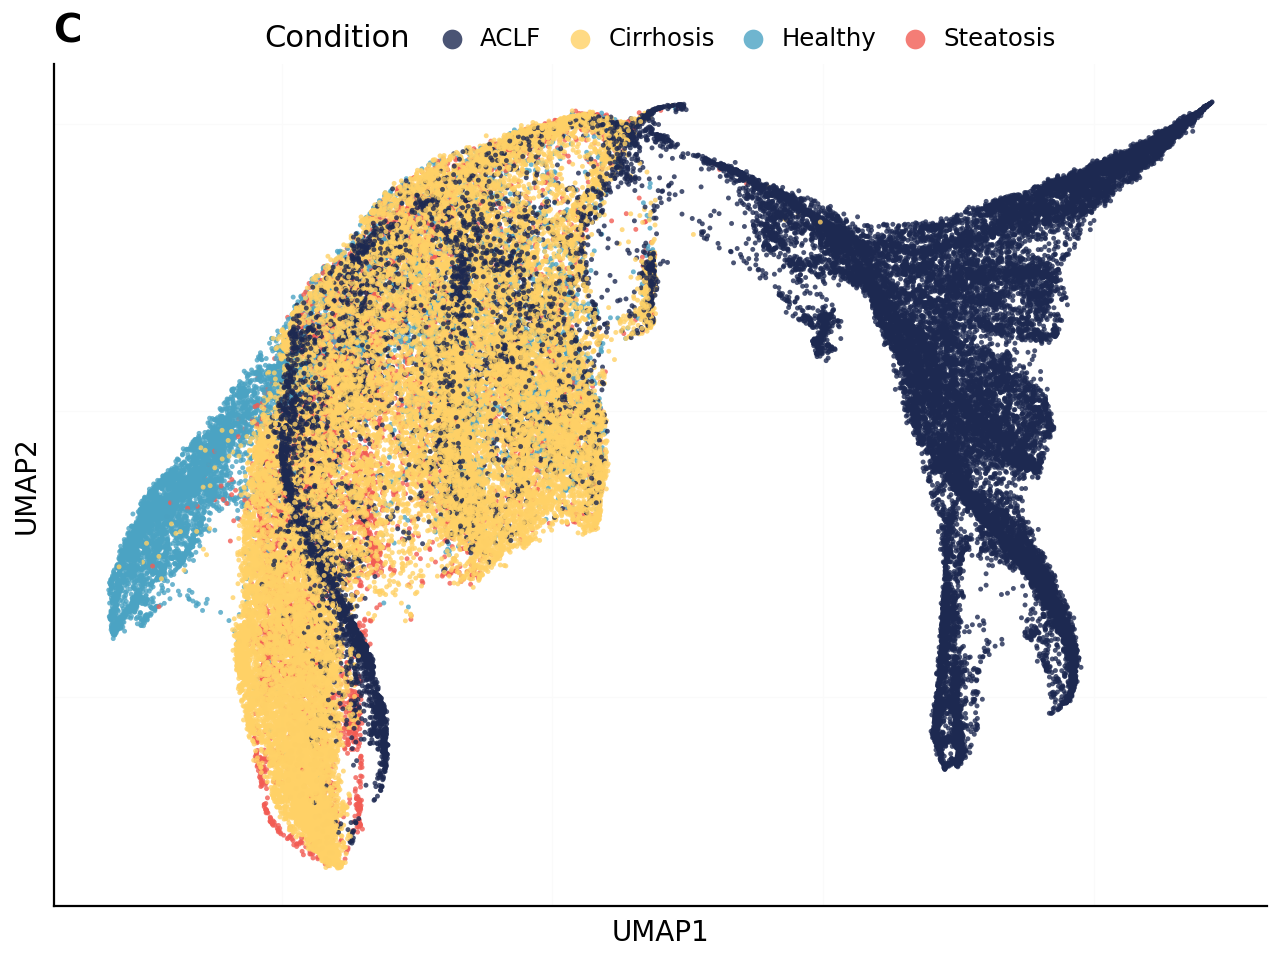

In [8]:
plot = (
    ggplot(data, aes(x="umap_1", y="umap_2", fill="condition"))
    + geom_point(alpha=0.8, size=1, stroke=0)
    + scale_fill_manual(values=custom_colors[:4])
    + labs(title="C", x="UMAP1", y="UMAP2", fill="Condition")
    + guides(fill=guide_legend(override_aes={"size": 4}))
    + figure_theme
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
        legend_position=(0.5, 1),
        legend_justification=(0.5, 0),
        legend_direction="horizontal",
        legend_background=element_rect(fill="white", color="none"),
    )
)

ggsave(plot, "output/initial_umap_condition.svg")

plot